In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = pd.read_csv("Concrete_Data.csv")
data.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [2]:
data = pd.read_csv("Concrete_Data.csv")
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')
print(data.columns.tolist())

['cement_(component_1)(kg_in_a_m^3_mixture)', 'blast_furnace_slag_(component_2)(kg_in_a_m^3_mixture)', 'fly_ash_(component_3)(kg_in_a_m^3_mixture)', 'water__(component_4)(kg_in_a_m^3_mixture)', 'superplasticizer_(component_5)(kg_in_a_m^3_mixture)', 'coarse_aggregate__(component_6)(kg_in_a_m^3_mixture)', 'fine_aggregate_(component_7)(kg_in_a_m^3_mixture)', 'age_(day)', 'concrete_compressive_strength(mpa,_megapascals)']


In [3]:
X = data[["coarse_aggregate__(component_6)(kg_in_a_m^3_mixture)"]].values
y = data["concrete_compressive_strength(mpa,_megapascals)"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()     
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_b = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_b = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)      
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)  
    return 1 - ss_res / ss_tot

def gradient_descent(X, y, lr=0.01, epochs=2000):
    theta = np.zeros(X.shape[1])
    for _ in range(epochs):
        y_pred = X.dot(theta)
        grad = (1/len(y)) * X.T.dot(y_pred - y)
        theta -= lr * grad
    return theta

theta = gradient_descent(X_train_b, y_train, lr=0.01, epochs=3000)

y_train_pred = X_train_b.dot(theta)
train_mse = mse(y_train, y_train_pred)
train_r2 = r2(y_train, y_train_pred)

y_test_pred = X_test_b.dot(theta)
test_mse = mse(y_test, y_test_pred)
test_r2 = r2(y_test, y_test_pred)

print(f"m (slope) = {theta[1]:.4f}")
print(f"b (intercept) = {theta[0]:.4f}")
print(f"MSE_train = {train_mse:.4f}")
print(f"R2_train = {train_r2:.4f}")
print(f"MSE_test = {test_mse:.4f}")
print(f"R2_test = {test_r2:.4f}")

m (slope) = -2.8925
b (intercept) = 35.8579
MSE_train = 275.7199
R2_train = 0.0295
MSE_test = 253.3261
R2_test = 0.0169


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


X = data[["blast_furnace_slag_(component_2)(kg_in_a_m^3_mixture)"]].values
y = data["concrete_compressive_strength(mpa,_megapascals)"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)


y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

m_slope = model.coef_[0]
b_intercept = model.intercept_

print("Cement as predictor")
print("m and b values:")
print(f"m (slope) = {m_slope:.4f}")
print(f"b (intercept) = {b_intercept:.4f}\n")
mse_train = mean_squared_error(y_train, y_pred_train)
print("MSE on training data:")
print(f"MSE_train = {mse_train:.4f}\n")


r2_train = r2_score(y_train, y_pred_train)
print("Variance Explained / R-Squared on training data:")
print(f"R2_train = {r2_train:.4f}\n")


mse_test = mean_squared_error(y_test, y_pred_test)
print("MSE on testing data:")
print(f"MSE_test = {mse_test:.4f}\n")


r2_test = r2_score(y_test, y_pred_test)
print("Variance Explained / R-Squared on testing data:")
print(f"R2_test = {r2_test:.4f}")

Cement as predictor
m and b values:
m (slope) = 2.6152
b (intercept) = 35.8579

MSE on training data:
MSE_train = 277.2472

Variance Explained / R-Squared on training data:
R2_train = 0.0241

MSE on testing data:
MSE_test = 260.3153

Variance Explained / R-Squared on testing data:
R2_test = -0.0102


In [5]:
X = data[["fly_ash_(component_3)(kg_in_a_m^3_mixture)"]].values
y = data["concrete_compressive_strength(mpa,_megapascals)"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



scaler = StandardScaler()      
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_b = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_b = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)      # residual sum of squares
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)  # total sum of squares
    return 1 - ss_res / ss_tot

def gradient_descent(X, y, lr=0.01, epochs=2000):
    theta = np.zeros(X.shape[1])
    for _ in range(epochs):
        y_pred = X.dot(theta)
        grad = (1/len(y)) * X.T.dot(y_pred - y)
        theta -= lr * grad
    return theta


theta = gradient_descent(X_train_b, y_train, lr=0.01, epochs=3000)

y_train_pred = X_train_b.dot(theta)
train_mse = mse(y_train, y_train_pred)
train_r2 = r2(y_train, y_train_pred)

y_test_pred = X_test_b.dot(theta)
test_mse = mse(y_test, y_test_pred)
test_r2 = r2(y_test, y_test_pred)

# ==== Display ====
print(f"m (slope) = {theta[1]:.4f}")
print(f"b (intercept) = {theta[0]:.4f}")
print(f"MSE_train = {train_mse:.4f}")
print(f"R2_train = {train_r2:.4f}")
print(f"MSE_test = {test_mse:.4f}")
print(f"R2_test = {test_r2:.4f}")

m (slope) = -2.5240
b (intercept) = 35.8579
MSE_train = 277.7158
R2_train = 0.0224
MSE_test = 270.4749
R2_test = -0.0497


In [6]:
X = data[["fly_ash_(component_3)(kg_in_a_m^3_mixture)"]].values
y = data["concrete_compressive_strength(mpa,_megapascals)"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()       #or MinMaxScaler() for normalization
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_b = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_b = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)      # residual sum of squares
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)  # total sum of squares
    return 1 - ss_res / ss_tot

def gradient_descent(X, y, lr=0.01, epochs=2000):
    theta = np.zeros(X.shape[1])
    for _ in range(epochs):
        y_pred = X.dot(theta)
        grad = (1/len(y)) * X.T.dot(y_pred - y)
        theta -= lr * grad
    return theta


theta = gradient_descent(X_train_b, y_train, lr=0.01, epochs=3000)

y_train_pred = X_train_b.dot(theta)
train_mse = mse(y_train, y_train_pred)
train_r2 = r2(y_train, y_train_pred)

y_test_pred = X_test_b.dot(theta)
test_mse = mse(y_test, y_test_pred)
test_r2 = r2(y_test, y_test_pred)

print(f"m (slope) = {theta[1]:.4f}")
print(f"b (intercept) = {theta[0]:.4f}")
print(f"MSE_train = {train_mse:.4f}")
print(f"R2_train = {train_r2:.4f}")
print(f"MSE_test = {test_mse:.4f}")
print(f"R2_test = {test_r2:.4f}")

m (slope) = -2.5240
b (intercept) = 35.8579
MSE_train = 277.7158
R2_train = 0.0224
MSE_test = 270.4749
R2_test = -0.0497


In [7]:
X = data[["coarse_aggregate__(component_6)(kg_in_a_m^3_mixture)"]]
y = data["concrete_compressive_strength(mpa,_megapascals)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=60)

x_train = X_train.values.flatten()
y_train = y_train.values
x_test = X_test.values.flatten()
y_test = y_test.values

x_mean, y_mean = np.mean(x_train), np.mean(y_train)
m = np.sum((x_train - x_mean) * (y_train - y_mean)) / np.sum((x_train - x_mean)**2)
b = y_mean - m * x_mean

y_pred_train = m * x_train + b
y_pred_test = m * x_test + b

mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"m (slope) = {m:.4f}")
print(f"b (intercept) = {b:.4f}")
print(f"MSE_train = {mse_train:.4f}")
print(f"R2_train = {r2_train:.4f}")
print(f"MSE_test = {mse_test:.4f}")
print(f"R2_test = {r2_test:.4f}")

m (slope) = -0.0411
b (intercept) = 75.7820
MSE_train = 269.9555
R2_train = 0.0372
MSE_test = 277.2723
R2_test = -0.0177


In [8]:
data = pd.read_csv("Concrete_Data.csv")
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')
print(data.columns.tolist())

['cement_(component_1)(kg_in_a_m^3_mixture)', 'blast_furnace_slag_(component_2)(kg_in_a_m^3_mixture)', 'fly_ash_(component_3)(kg_in_a_m^3_mixture)', 'water__(component_4)(kg_in_a_m^3_mixture)', 'superplasticizer_(component_5)(kg_in_a_m^3_mixture)', 'coarse_aggregate__(component_6)(kg_in_a_m^3_mixture)', 'fine_aggregate_(component_7)(kg_in_a_m^3_mixture)', 'age_(day)', 'concrete_compressive_strength(mpa,_megapascals)']


In [9]:
data = pd.read_csv("Concrete_Data.csv")
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')
X = data[['age_(day)']]
y = data['concrete_compressive_strength(mpa,_megapascals)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
m = model.coef_[0]
b = model.intercept_
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"m and b values: m = {m:.4f}, b = {b:.4f}")
print(f"MSE on training data: train_mse = {train_mse:.4f}")
print(f"Variance Explained / R-Squared on training data: train_r2 = {train_r2:.4f}")
print(f"MSE on testing data: test_mse = {test_mse:.4f}")
print(f"R2 on testing data: test_r2 = {test_r2:.4f}")


m and b values: m = 0.0926, b = 31.7219
MSE on training data: train_mse = 252.7593
Variance Explained / R-Squared on training data: train_r2 = 0.1103
MSE on testing data: test_mse = 232.9604
R2 on testing data: test_r2 = 0.0959


In [10]:
import numpy as np
m = np.array([1.0, 1.0, 1.0])  # m1, m2, m3
b = 1.0

x = np.array([3.0, 4.0, 5.0])
y = 4.0


alpha = 0.1

print("initiation:")
print(f"m1 = {m[0]}, m2 = {m[1]}, m3 = {m[2]}, b = {b}")

y_pred = np.dot(m, x) + b
print(f"\n prediction: {y_pred}")


error = y_pred - y
print(f"error: {error}")


grad_m = error * x
grad_b = error
print(f"\ngradient:")
print(f"∂L/∂m1 = {grad_m[0]}")
print(f"∂L/∂m2 = {grad_m[1]}")
print(f"∂L/∂m3 = {grad_m[2]}")
print(f"∂L/∂b = {grad_b}")


m_new = m - alpha * grad_m
b_new = b - alpha * grad_b

print(f"\nupdated parameter:")
print(f"New m1: {m_new[0]:.1f}")
print(f"New m2: {m_new[1]:.1f}")
print(f"New m3: {m_new[2]:.1f}")
print(f"New b: {b_new:.1f}")

y_pred_new = np.dot(m_new, x) + b_new
print(f"\ny_pred_new=: {y_pred_new}")
print(f"new error: {y_pred_new - y}")

initiation:
m1 = 1.0, m2 = 1.0, m3 = 1.0, b = 1.0

 prediction: 13.0
error: 9.0

gradient:
∂L/∂m1 = 27.0
∂L/∂m2 = 36.0
∂L/∂m3 = 45.0
∂L/∂b = 9.0

updated parameter:
New m1: -1.7
New m2: -2.6
New m3: -3.5
New b: 0.1

y_pred_new=: -32.9
new error: -36.9


In [11]:
class GradientDescent:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.m = None
        self.b = None
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.m = np.zeros(n_features)
        self.b = 0
        for i in range(self.n_iterations):
          
            y_pred = np.dot(X, self.m) + self.b
            
           
            error = y_pred - y
            grad_m = (1/n_samples) * np.dot(X.T, error)
            grad_b = (1/n_samples) * np.sum(error)
            
            
            self.m -= self.learning_rate * grad_m
            self.b -= self.learning_rate * grad_b
            

            if i % 100 == 0:
                mse = np.mean(error**2)
                print(f"Iteration {i}: MSE = {mse:.4f}")
    
    def predict(self, X):
        return np.dot(X, self.m) + self.b

data = pd.read_csv("Concrete_Data.csv")
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')

print("data columns:", data.columns.tolist())
X = data.drop('concrete_compressive_strength(mpa,_megapascals)', axis=1)
y = data['concrete_compressive_strength(mpa,_megapascals)']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\ntraining_set_size: {X_train_scaled.shape}")
print(f"testing_set_size: {X_test_scaled.shape}")


print("\ngradient descent model...")
gd_model = GradientDescent(learning_rate=0.01, n_iterations=1000)
gd_model.fit(X_train_scaled, y_train)

y_train_pred = gd_model.predict(X_train_scaled)
y_test_pred = gd_model.predict(X_test_scaled)


train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)


print("\n" + "="*50)
print("multivariate gradient descent result")
print("="*50)

print(f"\nm values:")
for i, m_val in enumerate(gd_model.m, 1):
    print(f"  m{i}: {m_val:.4f}")
print(f"b value: {gd_model.b:.4f}")

print("---")
print(f"MSE on training data: {train_mse:.4f}")
print("---")
print(f"Variance Explained / R-Squared on training data: {train_r2:.4f}")
print("---")
print(f"MSE on testing data: {test_mse:.4f}")
print(f"r2 on testing data: {test_r2:.4f}")

print("\n" + "="*50)
print("compare to linear regression in sklearn")
print("="*50)

from sklearn.linear_model import LinearRegression
sk_model = LinearRegression()
sk_model.fit(X_train_scaled, y_train)
y_train_sk = sk_model.predict(X_train_scaled)
train_r2_sk = r2_score(y_train, y_train_sk)

print(f"Sklearn R² on training data: {train_r2_sk:.4f}")
print(f"gradient descent R² on training data: {train_r2:.4f}")

data columns: ['cement_(component_1)(kg_in_a_m^3_mixture)', 'blast_furnace_slag_(component_2)(kg_in_a_m^3_mixture)', 'fly_ash_(component_3)(kg_in_a_m^3_mixture)', 'water__(component_4)(kg_in_a_m^3_mixture)', 'superplasticizer_(component_5)(kg_in_a_m^3_mixture)', 'coarse_aggregate__(component_6)(kg_in_a_m^3_mixture)', 'fine_aggregate_(component_7)(kg_in_a_m^3_mixture)', 'age_(day)', 'concrete_compressive_strength(mpa,_megapascals)']

training_set_size: (824, 8)
testing_set_size: (206, 8)

gradient descent model...
Iteration 0: MSE = 1569.8728
Iteration 100: MSE = 310.8380
Iteration 200: MSE = 144.6857
Iteration 300: MSE = 121.1494
Iteration 400: MSE = 116.9829
Iteration 500: MSE = 115.6912
Iteration 600: MSE = 114.9687
Iteration 700: MSE = 114.4483
Iteration 800: MSE = 114.0437
Iteration 900: MSE = 113.7182

multivariate gradient descent result

m values:
  m1: 8.4071
  m2: 5.1739
  m3: 1.3676
  m4: -5.7210
  m5: 2.1571
  m6: -1.5010
  m7: -1.9247
  m8: 6.8291
b value: 35.8563
---
MSE o

In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

data = pd.read_csv("Concrete_Data.csv")
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')

print("data columns:", data.columns.tolist())
X = data.drop('concrete_compressive_strength(mpa,_megapascals)', axis=1)
y = data['concrete_compressive_strength(mpa,_megapascals)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_b = np.c_[np.ones(X_train.shape[0]), X_train]
X_test_b = np.c_[np.ones(X_test.shape[0]), X_test]

def gradient_descent(X, y, lr=1e-6, epochs=20000):
    n_samples, n_features = X.shape
    theta = np.zeros(n_features)
    for _ in range(epochs):
        y_pred = X.dot(theta)
        grad = (1/n_samples) * X.T.dot(y_pred - y)
        theta -= lr * grad
    return theta

theta = gradient_descent(X_train_b, y_train, lr=1e-6, epochs=20000)

y_pred_train = X_train_b.dot(theta)
y_pred_test = X_test_b.dot(theta)

mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("==== Model Parameters ====")
print(f"b (intercept) = {theta[0]:.4f}")
for i, col in enumerate(X.columns):
    print(f"m{i+1}  = {theta[i+1]:.6f}")

print("\n==== Performance ====")
print(f"MSE_train = {mse_train:.4f}")
print(f"R2_train = {r2_train:.4f}")
print(f"MSE_test = {mse_test:.4f}")
print(f"R2_test = {r2_test:.4f}")


data columns: ['cement_(component_1)(kg_in_a_m^3_mixture)', 'blast_furnace_slag_(component_2)(kg_in_a_m^3_mixture)', 'fly_ash_(component_3)(kg_in_a_m^3_mixture)', 'water__(component_4)(kg_in_a_m^3_mixture)', 'superplasticizer_(component_5)(kg_in_a_m^3_mixture)', 'coarse_aggregate__(component_6)(kg_in_a_m^3_mixture)', 'fine_aggregate_(component_7)(kg_in_a_m^3_mixture)', 'age_(day)', 'concrete_compressive_strength(mpa,_megapascals)']
==== Model Parameters ====
b (intercept) = -0.0001
m1  = 0.116248
m2  = 0.105326
m3  = 0.082136
m4  = -0.194879
m5  = 0.093015
m6  = 0.007594
m7  = 0.016794
m8  = 0.116774

==== Performance ====
MSE_train = 111.2490
R2_train = 0.6084
MSE_test = 95.9207
R2_test = 0.6277


In [13]:
import statsmodels.api as sm

data = pd.read_csv("Concrete_Data.csv")
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')
print(data.columns.tolist())

X = data.drop(columns=['concrete_compressive_strengthmpa,_megapascals'])
y = data['concrete_compressive_strengthmpa,_megapascals']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

model = sm.OLS(y_train, X_train_const).fit()

y_train_pred = model.predict(X_train_const)
y_test_pred = model.predict(X_test_const)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("==== Regression Summary ====")
print(model.summary())   # includes t-statistics and p-values

print("\n==== Performance ====")
print(f"MSE (train) = {mse_train:.4f}")
print(f"MSE (test)  = {mse_test:.4f}")
print(f"R2 (train)  = {r2_train:.4f}")
print(f"R2 (test)  = {r2_test:.4f}")


['cement_component_1kg_in_a_m^3_mixture', 'blast_furnace_slag_component_2kg_in_a_m^3_mixture', 'fly_ash_component_3kg_in_a_m^3_mixture', 'water__component_4kg_in_a_m^3_mixture', 'superplasticizer_component_5kg_in_a_m^3_mixture', 'coarse_aggregate__component_6kg_in_a_m^3_mixture', 'fine_aggregate_component_7kg_in_a_m^3_mixture', 'age_day', 'concrete_compressive_strengthmpa,_megapascals']
==== Regression Summary ====
                                          OLS Regression Results                                         
Dep. Variable:     concrete_compressive_strengthmpa,_megapascals   R-squared:                       0.611
Model:                                                       OLS   Adj. R-squared:                  0.607
Method:                                            Least Squares   F-statistic:                     159.7
Date:                                           Fri, 17 Oct 2025   Prob (F-statistic):          3.46e-161
Time:                                              

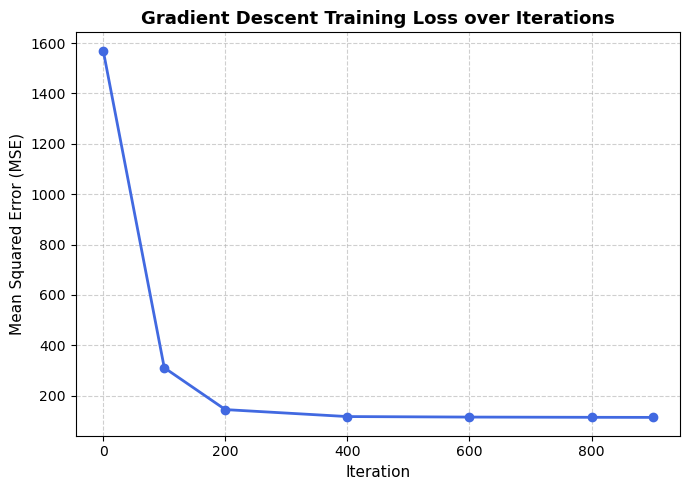

In [14]:
import matplotlib.pyplot as plt

iterations = [0, 100, 200, 400, 600, 800, 900]
mse_values = [1569.87, 310.84, 144.69, 116.98, 114.97, 114.04, 113.72]


plt.figure(figsize=(7, 5))
plt.plot(iterations, mse_values, marker='o', linestyle='-', linewidth=2.0, markersize=6, color='royalblue')

plt.title("Gradient Descent Training Loss over Iterations", fontsize=13, weight='bold')
plt.xlabel("Iteration", fontsize=11)
plt.ylabel("Mean Squared Error (MSE)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()


plt.savefig("loss_over_iterations.png", dpi=300)
plt.show()


In [15]:
print(data.columns.tolist())

['cement_component_1kg_in_a_m^3_mixture', 'blast_furnace_slag_component_2kg_in_a_m^3_mixture', 'fly_ash_component_3kg_in_a_m^3_mixture', 'water__component_4kg_in_a_m^3_mixture', 'superplasticizer_component_5kg_in_a_m^3_mixture', 'coarse_aggregate__component_6kg_in_a_m^3_mixture', 'fine_aggregate_component_7kg_in_a_m^3_mixture', 'age_day', 'concrete_compressive_strengthmpa,_megapascals']


In [16]:
data = pd.read_csv("Concrete_Data.csv")
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

X = data.drop(columns=['concrete_compressive_strengthmpa,_megapascals'])
y = data['concrete_compressive_strengthmpa,_megapascals']

# standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_const = sm.add_constant(X_scaled)
model_scaled = sm.OLS(y, X_scaled_const).fit()

print(model_scaled.summary())

                                          OLS Regression Results                                         
Dep. Variable:     concrete_compressive_strengthmpa,_megapascals   R-squared:                       0.616
Model:                                                       OLS   Adj. R-squared:                  0.613
Method:                                            Least Squares   F-statistic:                     204.3
Date:                                           Fri, 17 Oct 2025   Prob (F-statistic):          6.29e-206
Time:                                                   19:24:41   Log-Likelihood:                -3869.0
No. Observations:                                           1030   AIC:                             7756.
Df Residuals:                                               1021   BIC:                             7800.
Df Model:                                                      8                                         
Covariance Type:                              

In [17]:
X_log = np.log(X + 1)
X_log_const = sm.add_constant(X_log)
model_log = sm.OLS(y, X_log_const).fit()
print(model_log.summary())

                                          OLS Regression Results                                         
Dep. Variable:     concrete_compressive_strengthmpa,_megapascals   R-squared:                       0.803
Model:                                                       OLS   Adj. R-squared:                  0.801
Method:                                            Least Squares   F-statistic:                     520.2
Date:                                           Fri, 17 Oct 2025   Prob (F-statistic):               0.00
Time:                                                   19:24:41   Log-Likelihood:                -3524.6
No. Observations:                                           1030   AIC:                             7067.
Df Residuals:                                               1021   BIC:                             7112.
Df Model:                                                      8                                         
Covariance Type:                              

R2_train = 0.611, R2_test = 0.628


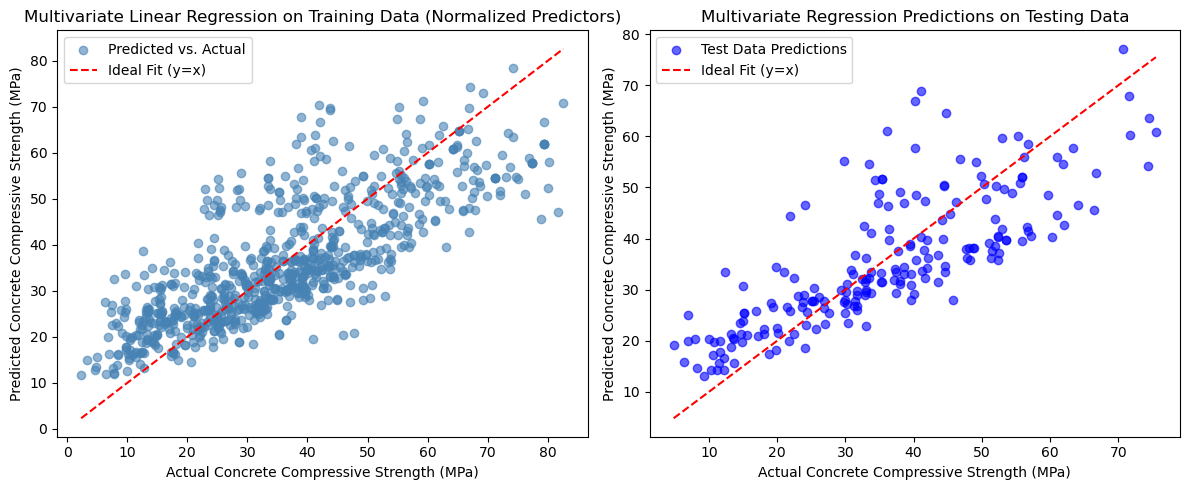

Training Variance Explained (R-squared): 0.611
Testing Variance Explained (R-squared): 0.628

P-values for Each Input Feature:
                                              Feature    p-Value
1          Cement (component 1)(kg in a m^3 mixture)  9.103e-34
2  Blast Furnace Slag (component 2)(kg in a m^3 m...  1.044e-20
3         Fly Ash (component 3)(kg in a m^3 mixture)  9.029e-09
4           Water (component 4)(kg in a m^3 mixture)  2.243e-03
5  Superplasticizer (component 5)(kg in a m^3 mix...  2.988e-03
6  Coarse Aggregate (component 6)(kg in a m^3 mix...  8.603e-02
7  Fine Aggregate (component 7)(kg in a m^3 mixture)  4.227e-02
8                                          Age (day)  6.417e-62


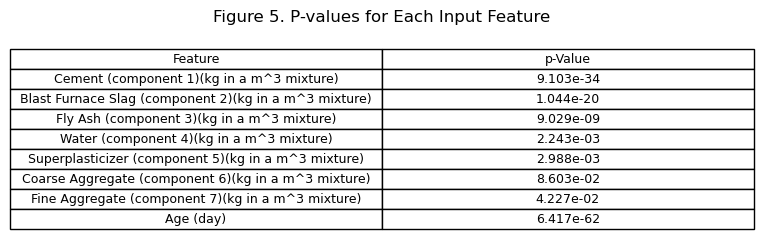

In [18]:
df = pd.read_csv("Concrete_Data.csv")
cols = (
    df.columns.str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("(", "", regex=False)
      .str.replace(")", "", regex=False)
      .str.replace(",", "", regex=False)
)
df.columns = cols

# ======Identify target======
target_candidates = [c for c in df.columns if "compressive_strength" in c or "strength" in c]
y_col = target_candidates[0]
y = df[y_col].values
X = df.drop(columns=[y_col])
feature_names = list(X.columns)

# ======Standardize predictors======
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ======Split train/test======
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ======Fit OLS======
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)
model = sm.OLS(y_train, X_train_const).fit()

# ======Predict======
y_pred_train = model.predict(X_train_const)
y_pred_test = model.predict(X_test_const)

# ======R2======
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
print(f"R2_train = {r2_train:.3f}, R2_test = {r2_test:.3f}")

plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.scatter(y_train, y_pred_train, color="steelblue", alpha=0.6, label="Predicted vs. Actual")
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         'r--', label="Ideal Fit (y=x)")
plt.xlabel("Actual Concrete Compressive Strength (MPa)")
plt.ylabel("Predicted Concrete Compressive Strength (MPa)")
plt.title("Multivariate Linear Regression on Training Data (Normalized Predictors)")
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_test, color="blue", alpha=0.6, label="Test Data Predictions")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', label="Ideal Fit (y=x)")
plt.xlabel("Actual Concrete Compressive Strength (MPa)")
plt.ylabel("Predicted Concrete Compressive Strength (MPa)")
plt.title("Multivariate Regression Predictions on Testing Data")
plt.legend()

plt.tight_layout()
plt.savefig("actual_vs_predicted_train_test.png", dpi=200)
plt.show()

print(f"Training Variance Explained (R-squared): {r2_train:.3f}")
print(f"Testing Variance Explained (R-squared): {r2_test:.3f}")

results = pd.DataFrame({
    "Feature": ["Cement (component 1)(kg in a m^3 mixture)",
                "Blast Furnace Slag (component 2)(kg in a m^3 mixture)",
                "Fly Ash (component 3)(kg in a m^3 mixture)",
                "Water (component 4)(kg in a m^3 mixture)",
                "Superplasticizer (component 5)(kg in a m^3 mixture)",
                "Coarse Aggregate (component 6)(kg in a m^3 mixture)",
                "Fine Aggregate (component 7)(kg in a m^3 mixture)",
                "Age (day)"],
    "p-Value": model.pvalues[1:]  # exclude intercept
})
results["p-Value"] = results["p-Value"].apply(lambda x: f"{x:.3e}")
results.index = np.arange(1, len(results)+1)
print("\nP-values for Each Input Feature:\n", results)


fig, ax = plt.subplots(figsize=(8, 2.5))
ax.axis('off')
table = ax.table(cellText=results.values,
                 colLabels=results.columns,
                 cellLoc='center',
                 loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.2)
plt.title("Figure 5. P-values for Each Input Feature", pad=15)
plt.savefig("p_values_table.png", dpi=200, bbox_inches="tight")
plt.show()

# Save numeric R² summary
with open("r2_summary.txt", "w") as f:
    f.write(f"Training R² = {r2_train:.3f}\nTesting R² = {r2_test:.3f}\n")


In [19]:
model = sm.OLS(y_train, X_train_const).fit()
print("\nFinal parameter estimates (OLS coefficients):")
for name, coef in zip(["Intercept"] + feature_names, model.params):
    print(f"{name}: {coef:.2f}")
    


Final parameter estimates (OLS coefficients):
Intercept: 35.81
cement_component_1kg_in_a_m^3_mixture: 12.43
blast_furnace_slag_component_2kg_in_a_m^3_mixture: 9.36
fly_ash_component_3kg_in_a_m^3_mixture: 5.25
water__component_4kg_in_a_m^3_mixture: -2.89
superplasticizer_component_5kg_in_a_m^3_mixture: 1.85
coarse_aggregate__component_6kg_in_a_m^3_mixture: 1.39
fine_aggregate_component_7kg_in_a_m^3_mixture: 1.93
age_day: 7.35
